# LightGBM


In [14]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ml_final_project


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ml_final_project


In [15]:
import os
if not os.path.exists('/content/ml_final_project'):
    !git clone -q https://github.com/ochiga07/ml_final_project.git /content/ml_final_project
import sys
sys.path.append('/content/ml_final_project')

from colab_setup import setup_project

drive_repo = setup_project(repo_url="https://github.com/ochiga07/ml_final_project.git")

import feature_pipeline
import importlib
importlib.reload(feature_pipeline)
from feature_pipeline import load_raw_data, run_feature_pipeline

from metrics import wmae
from walmart_lgbm import WalmartLGBMPipeline, prepare_xy


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!pip install -q lightgbm mlflow dagshub


In [17]:
import os
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import dagshub

if 'DAGSHUB_USER_TOKEN' not in os.environ:
    try:
        from google.colab import userdata
        os.environ['DAGSHUB_USER_TOKEN'] = userdata.get('DAGSHUB_USER_TOKEN')
    except Exception:
        pass

dagshub.init(repo_owner='aochi23', repo_name='ml_final_project', mlflow=True)
mlflow.set_experiment('LightGBM_Training')


Initialized MLflow to track repo "aochi23/ml_final_project"

Repository aochi23/ml_final_project initialized!

<Experiment: artifact_location='mlflow-artifacts:/f60a21fc9b724f40831da04f2dc55f0f', creation_time=1783723710224, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1783723710224, lifecycle_stage='active', name='LightGBM_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

## Data


In [18]:
train, test, features, stores = load_raw_data(path=f'{drive_repo}/data/')
full_df = run_feature_pipeline(train, test, features, stores)

train_df = full_df[full_df['is_train'] == 1].drop(columns=['is_train'])
print(train_df.shape)
train_df.head()


(421570, 39)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,lag_52,lag_53,rolling_mean_4,rolling_mean_8,rolling_std_4,rolling_std_8,yoy_growth,dept_avg_sales,store_avg_sales,type_ordinal
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19213.485088,21710.543621,3
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19213.485088,21710.543621,3
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19213.485088,21710.543621,3
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19213.485088,21710.543621,3
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,NaN,NaN,32990.77,NaN,12832.106391,NaN,NaN,19213.485088,21710.543621,3


## Train/val split


In [19]:
VAL_WEEKS = 12

FEATURES = [
    'Store', 'Dept', 'IsHoliday', 'Type', 'Size',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'markdown_total', 'n_active_markdowns',
    'week_of_year', 'month', 'year', 'days_to_nearest_holiday', 'is_week_after_thanksgiving',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_52', 'lag_53',
    'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4', 'rolling_std_8',
    'yoy_growth', 'dept_avg_sales', 'store_avg_sales', 'type_ordinal', 'n_weeks',
]

FEATURES_SMALL = [
    'Store', 'Dept', 'IsHoliday', 'Type', 'Size',
    'week_of_year', 'month', 'days_to_nearest_holiday',
    'lag_1', 'lag_4', 'lag_52',
    'rolling_mean_4', 'rolling_mean_8',
    'dept_avg_sales', 'store_avg_sales',
]

BASE_PARAMS = {
    'objective': 'regression_l1',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose': -1,
}

cutoff = train_df['Date'].max() - pd.Timedelta(weeks=VAL_WEEKS)
train_part = train_df[train_df['Date'] < cutoff].copy()
val_part = train_df[train_df['Date'] >= cutoff].copy()

print('Train:', train_part['Date'].min(), 'to', train_part['Date'].max())
print('Val:  ', val_part['Date'].min(), 'to', val_part['Date'].max())


Train: 2010-02-05 00:00:00 to 2012-07-27 00:00:00
Val:   2012-08-03 00:00:00 to 2012-10-26 00:00:00


In [20]:
def eval_model(model, X, y, holidays):
    preds = model.predict(X)
    return wmae(y.values, preds, holidays.values)


def train_lgbm(X_train, y_train, X_val, y_val, params, sample_weight=None):
    model = lgb.LGBMRegressor(**params)
    fit_kwargs = {}
    if sample_weight is not None:
        fit_kwargs['sample_weight'] = sample_weight

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='l1',
        callbacks=[lgb.early_stopping(50, verbose=False)],
        **fit_kwargs,
    )
    return model


## LightGBM_Cleaning


In [21]:
with mlflow.start_run(run_name='LightGBM_Cleaning'):
    tr = train_part.dropna(subset=['lag_52'])
    va = val_part.dropna(subset=['lag_52'])

    X_tr = prepare_xy(tr, FEATURES)
    X_va = prepare_xy(va, FEATURES)

    model = train_lgbm(X_tr, tr['Weekly_Sales'], X_va, va['Weekly_Sales'], BASE_PARAMS)
    score = eval_model(model, X_va, va['Weekly_Sales'], va['IsHoliday'])

    mlflow.log_param('n_features', len(FEATURES))
    mlflow.log_metric('val_wmae', score)
    print(f'Cleaning - val WMAE: {score:.4f}')


Cleaning - val WMAE: 1251.0165
🏃 View run LightGBM_Cleaning at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/4/runs/f5914a8da3eb4e5b9e8caecf42de9822
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/4


## LightGBM_Feature_Selection


In [22]:
with mlflow.start_run(run_name='LightGBM_Feature_Selection'):
    tr = train_part.dropna(subset=['lag_52'])
    va = val_part.dropna(subset=['lag_52'])

    X_tr = prepare_xy(tr, FEATURES_SMALL)
    X_va = prepare_xy(va, FEATURES_SMALL)

    model = train_lgbm(X_tr, tr['Weekly_Sales'], X_va, va['Weekly_Sales'], BASE_PARAMS)
    score = eval_model(model, X_va, va['Weekly_Sales'], va['IsHoliday'])

    mlflow.log_param('n_features', len(FEATURES_SMALL))
    mlflow.log_metric('val_wmae', score)
    print(f'Feature selection - val WMAE: {score:.4f}')
    # full features had better wmae, using them for final


Feature selection - val WMAE: 1256.7735
🏃 View run LightGBM_Feature_Selection at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/4/runs/68a5c5d1f1f846f3a8dd94109d7ba048
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/4


## LightGBM_HPO


In [23]:
param_grid = [
    {'num_leaves': 31, 'learning_rate': 0.05},
    {'num_leaves': 63, 'learning_rate': 0.05},
    {'num_leaves': 31, 'learning_rate': 0.03},
]

hpo_results = []

with mlflow.start_run(run_name='LightGBM_HPO'):
    tr = train_part.dropna(subset=['lag_52'])
    va = val_part.dropna(subset=['lag_52'])
    X_tr = prepare_xy(tr, FEATURES)
    X_va = prepare_xy(va, FEATURES)
    sw = tr['IsHoliday'].map({True: 5, False: 1}).values

    for i, extra in enumerate(param_grid):
        params = BASE_PARAMS.copy()
        params.update(extra)

        model = train_lgbm(X_tr, tr['Weekly_Sales'], X_va, va['Weekly_Sales'], params, sw)
        score = eval_model(model, X_va, va['Weekly_Sales'], va['IsHoliday'])

        mlflow.log_metric(f'wmae_combo_{i+1}', score)
        hpo_results.append({'wmae': score, **extra})
        print(f'HPO combo {i+1} - val WMAE: {score:.4f}')

hpo_df = pd.DataFrame(hpo_results).sort_values('wmae')
hpo_df


HPO combo 1 - val WMAE: 1292.2048
HPO combo 2 - val WMAE: 1286.8010
HPO combo 3 - val WMAE: 1268.7266
🏃 View run LightGBM_HPO at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/4/runs/39aaab85083d43dda9fecc46f9b5b58b
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/4


,wmae,num_leaves,learning_rate
2,1268.726579,31,0.03
1,1286.801035,63,0.05
0,1292.204803,31,0.05


## LightGBM_Final


2026/07/11 08:53:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Walmart_LightGBM' already exists. Creating a new version of this model...
2026/07/11 08:54:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Walmart_LightGBM, version 2
Created version '2' of model 'Walmart_LightGBM'.


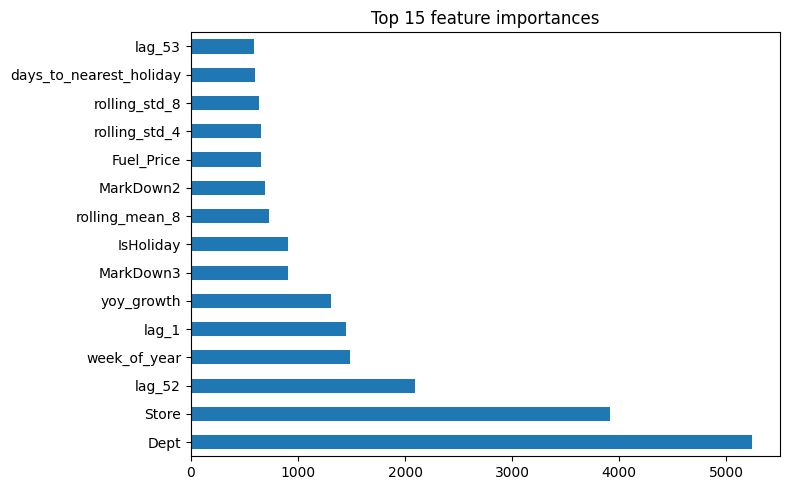

Final - val WMAE: 1268.7266
🏃 View run LightGBM_Final at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/4/runs/4f67ce1d6742417681d29f8dda531a55
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/4


In [24]:
best = hpo_df.iloc[0]
FINAL_PARAMS = BASE_PARAMS.copy()
FINAL_PARAMS['num_leaves'] = int(best['num_leaves'])
FINAL_PARAMS['learning_rate'] = float(best['learning_rate'])

with mlflow.start_run(run_name='LightGBM_Final') as run:
    tr = train_part.dropna(subset=['lag_52'])
    va = val_part.dropna(subset=['lag_52'])

    X_tr = prepare_xy(tr, FEATURES)
    X_va = prepare_xy(va, FEATURES)
    sw = tr['IsHoliday'].map({True: 5, False: 1}).values

    lgb_model = train_lgbm(X_tr, tr['Weekly_Sales'], X_va, va['Weekly_Sales'], FINAL_PARAMS, sw)
    score = eval_model(lgb_model, X_va, va['Weekly_Sales'], va['IsHoliday'])

    pipeline = WalmartLGBMPipeline(feature_cols=FEATURES, lgb_params=FINAL_PARAMS)
    pipeline.set_raw_data(train, features, stores)
    pipeline.fit(X_tr, tr['Weekly_Sales'])
    pipeline.model_ = lgb_model

    mlflow.log_params(FINAL_PARAMS)
    mlflow.log_metric('val_wmae', score)
    mlflow.sklearn.log_model(
        pipeline,
        name='lightgbm_pipeline',
        registered_model_name='Walmart_LightGBM',
        serialization_format='cloudpickle',
        code_paths=[
            f'{drive_repo}/src/feature_pipeline.py',
            f'{drive_repo}/src/walmart_lgbm.py',
            f'{drive_repo}/src/metrics.py',
        ],
    )

    imp = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    imp.plot(kind='barh', ax=ax)
    ax.set_title('Top 15 feature importances')
    plt.tight_layout()
    fig.savefig(f'{drive_repo}/lgbm_feature_importance.png')
    mlflow.log_artifact(f'{drive_repo}/lgbm_feature_importance.png')
    plt.show()

    print(f'Final - val WMAE: {score:.4f}')


## Register model


In [25]:
model_uri = 'models:/Walmart_LightGBM/latest'
loaded = mlflow.sklearn.load_model(model_uri)
raw_test = test[['Store', 'Dept', 'Date', 'IsHoliday']].head(100)
preds = loaded.predict(raw_test)
print(f'raw test predict ok: {len(preds)} predictions')


raw test predict ok: 100 predictions
